Dataset Shape: (4269, 13)
Columns: Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')
income_annum , 

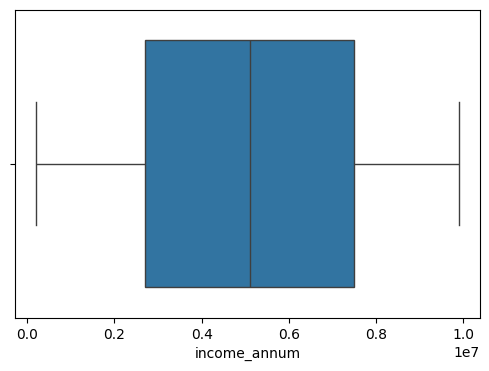

loan_amount , 

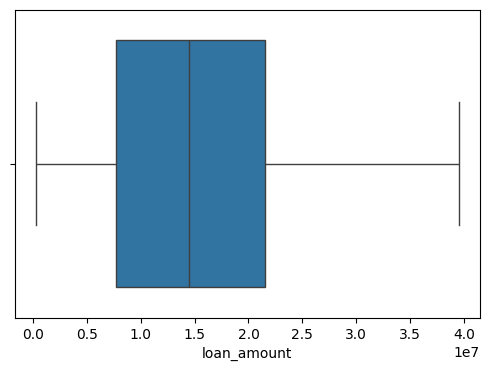

loan_term , 

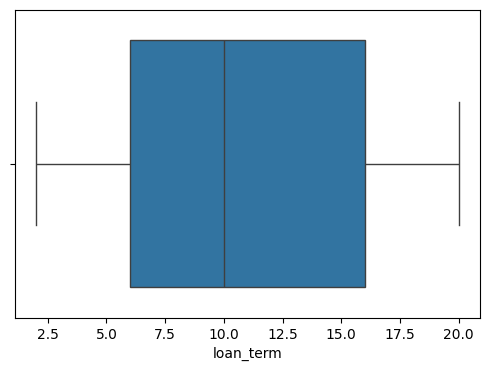

cibil_score , 

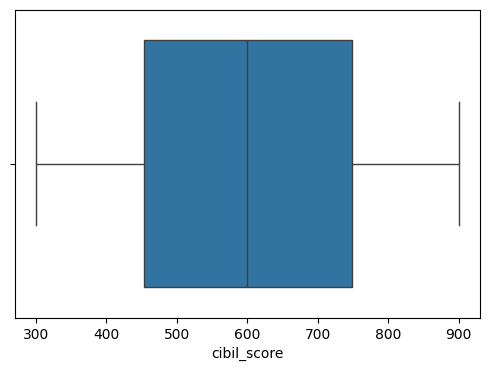

assets_value , 

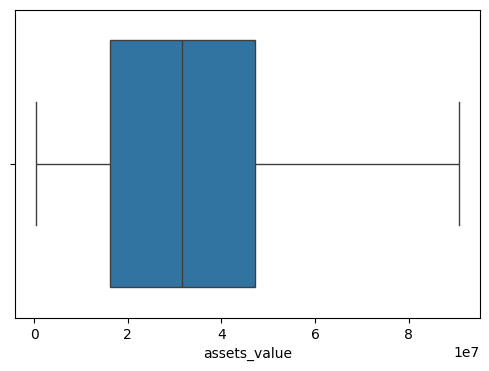

--------------------------------------------------
ENTER VALUES FOR PREDICTION:


Enter Education (1=Graduate, 0=Not Graduate):  1
Enter Self Employed (1=Yes, 0=No):  1
Enter Annual Income:  1200000
Enter Loan Amount:  1500000
Enter Loan Term:  2
Enter Total Assets Value:  2000000
Enter Loan Status (1=Approved, 0=Rejected):  1


--------------------------------------------------
Predicted Credit Score: 319
Decision (Credit Score Category): Poor

Model Accuracy: 100.0 %

Confusion Matrix:
 [[1983    0    0]
 [   0  638    0]
 [   0    0 1648]]


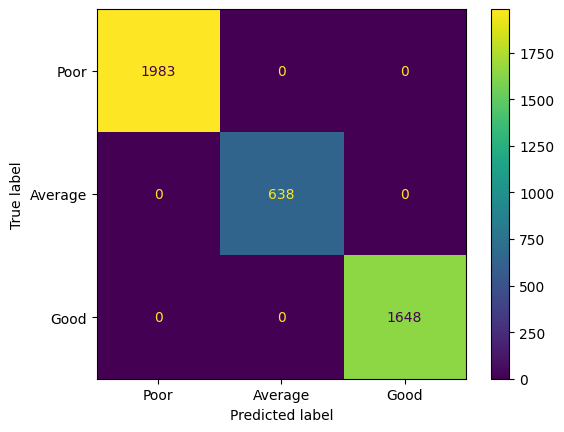

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv("../DataSet/loan_approval_dataset.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)
print("Columns:", df.columns)

# Create total assets column if missing
if 'assets_value' not in df.columns:
    df['assets_value'] = (
        df['residential_assets_value'] +
        df['commercial_assets_value'] +
        df['luxury_assets_value'] +
        df['bank_asset_value']
    )

# Outlier check (only numeric columns)
col = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'assets_value']

for i in col:
    print(i, end=" , ")
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[i])
    plt.show()

# Convert categorical columns into numbers
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

# Feature Selection
features = [
    'education',
    'self_employed',
    'income_annum',
    'loan_amount',
    'loan_term',
    'assets_value',
    'loan_status'
]

X = df[features]
y = df['cibil_score']

# Train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

# USER INPUT
print("-" * 50)
print("ENTER VALUES FOR PREDICTION:")

education = int(input("Enter Education (1=Graduate, 0=Not Graduate): "))
self_employed = int(input("Enter Self Employed (1=Yes, 0=No): "))
income = float(input("Enter Annual Income: "))
loan_amt = float(input("Enter Loan Amount: "))
loan_term = float(input("Enter Loan Term: "))
assets = float(input("Enter Total Assets Value: "))
loan_status = int(input("Enter Loan Status (1=Approved, 0=Rejected): "))

# Prediction
pred_score = model.predict([[education, self_employed, income, loan_amt, loan_term, assets, loan_status]])[0]

print("-" * 50)
print("Predicted Credit Score:", round(pred_score, 2))

# Categorize score
def categorize_score(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Average'
    else:
        return 'Good'

decision = categorize_score(pred_score)
print("Decision (Credit Score Category):", decision)

# Model Evaluation
y_actual_cat = y.apply(categorize_score)
y_pred_continuous = model.predict(X)
y_pred_cat = pd.Series(y_pred_continuous).apply(categorize_score)

acc = accuracy_score(y_actual_cat, y_pred_cat) * 100
print("\nModel Accuracy:", round(acc, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_actual_cat, y_pred_cat, labels=['Poor', 'Average', 'Good'])
print("\nConfusion Matrix:\n", cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Average', 'Good'])
disp.plot()
plt.show()